**Previously on:** Lecture 27 asked "is this one point real, or is it just noise?" and built two
rules to answer it. Today generalizes that same question from a single point to a whole
*difference* between two groups: "is this weird gap real, or could it just be chance?" Lecture 5
taught you to describe a distribution -- mean, std dev, spread. Today we compare *two*
distributions and ask whether the difference between them is real, using nothing more than that
same vocabulary plus one new function.

Today's topics:
* the null hypothesis, stated plainly
* the p-value, without mysticism: the probability of a difference this big if nothing were
  actually going on
* the two-sample t-test, `scipy.stats.ttest_ind`
* a null result and a real result, from the same tool, on real materials data

> By the end of today you should be able to complete Problems 1-3 of Homework 9: run a two-sample
> test on a provided pair of groups and write the conclusion as a sentence a shop manager could
> act on.

# The question: is grid or honeycomb actually stronger?

## Dataset: 3D Printing (FDM) Parameters

Data come from [this github repository](https://github.com/ahmetokudan/3dprinterdeeplearning)
and are provided with an unlimited license (public domain).

In [1]:
import os
import pandas as pd

_file = '3dprinting.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}', f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    data = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e
data.head()  # show a view of the data file

,layer_height (mm),wall_thickness (mm),infill_density (%),infill_pattern,nozzle_temperature (degC),bed_temperature (degC),print_velocity (mm/s),material,fan_speed (%),roughness (microns),tension_strength (Mpa),elongation (%)
0,0.02,8,90,grid,220,60,40,abs,0,25,18,1.2
1,0.02,7,90,honeycomb,225,65,40,abs,25,32,16,1.4
2,0.02,1,80,grid,230,70,40,abs,50,40,8,0.8
3,0.02,4,70,honeycomb,240,75,40,abs,75,68,10,0.5
4,0.02,6,90,grid,250,80,40,abs,100,92,5,0.7


### Why this one?

3D printing (FDM) turns a handful of dial-in settings — layer height, infill density
and pattern, nozzle/bed temperature, print speed — into a physical part with real
mechanical properties. This is a compact, tangible example of the "process determines
structure determines properties" idea central to materials science: does printing
faster or hotter make a part stronger, or just rougher?

In [2]:
print(data[['material', 'infill_pattern']].describe(include='object'))
data.describe()

       material infill_pattern
count        50             50
unique        2              2
top         abs           grid
freq         25             25


,layer_height (mm),wall_thickness (mm),infill_density (%),nozzle_temperature (degC),bed_temperature (degC),print_velocity (mm/s),fan_speed (%),roughness (microns),tension_strength (Mpa),elongation (%)
count,50.000000,50.000000,50.00000,50.000000,50.000000,50.0000,50.000000,50.000000,50.000000,50.000000
mean,0.106000,5.220000,53.40000,221.500000,70.000000,64.0000,50.000000,170.580000,20.080000,1.672000
std,0.064397,2.922747,25.36348,14.820353,7.142857,29.6923,35.714286,99.034129,8.925634,0.788188
min,0.020000,1.000000,10.00000,200.000000,60.000000,40.0000,0.000000,21.000000,4.000000,0.400000
25%,0.060000,3.000000,40.00000,210.000000,65.000000,40.0000,25.000000,92.000000,12.000000,1.100000
50%,0.100000,5.000000,50.00000,220.000000,70.000000,60.0000,50.000000,165.500000,19.000000,1.550000
75%,0.150000,7.000000,80.00000,230.000000,75.000000,60.0000,75.000000,239.250000,27.000000,2.175000
max,0.200000,10.000000,90.00000,250.000000,80.000000,120.0000,100.000000,368.000000,37.000000,3.300000


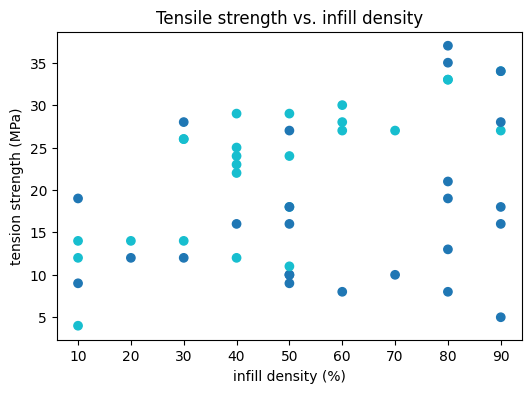

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(data['infill_density (%)'], data['tension_strength (Mpa)'],
           c=data['material'].astype('category').cat.codes, cmap='tab10')
ax.set_xlabel('infill density (%)')
ax.set_ylabel('tension strength (MPa)')
ax.set_title('Tensile strength vs. infill density')
plt.show()

50 FDM prints, split evenly between two infill patterns. Split by `infill_pattern` and print each
group's size and mean tensile strength:

In [4]:
printing_data = data  # keep a handle on this table -- reused by name again in Section 6
grid = printing_data[printing_data['infill_pattern'] == 'grid']['tension_strength (Mpa)']
honeycomb = printing_data[printing_data['infill_pattern'] == 'honeycomb']['tension_strength (Mpa)']
print(f'grid:      n={len(grid)}, mean={grid.mean():.2f} MPa, std={grid.std():.2f} MPa')
print(f'honeycomb: n={len(honeycomb)}, mean={honeycomb.mean():.2f} MPa, std={honeycomb.std():.2f} MPa')

grid:      n=25, mean=20.00 MPa, std=9.39 MPa
honeycomb: n=25, mean=20.16 MPa, std=8.62 MPa


A 0.16 MPa gap between two group means, each with a standard deviation around 8-9 MPa. Pose the
question cold, before any statistics vocabulary: if I only printed 25 of each, and print strength
has some batch-to-batch noise, how do I know this gap isn't just noise? If I reprinted 25 more of
each tomorrow, would the "stronger" pattern even come out the same? A print shop choosing between
infill patterns needs a real answer to that, not a vibe -- a question with a purchase-order
answer. Keep that 0.16 MPa number in your head; it's small, and that observation pays off in
Section 4.

# Visualize both distributions, not just the means

Two overlapping histograms, direct callback to Lecture 5:

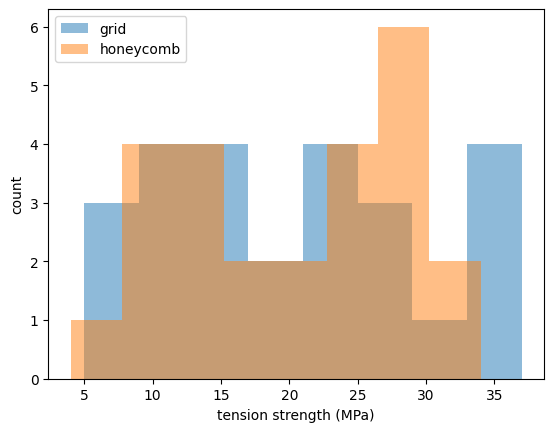

In [5]:
plt.hist(grid, alpha=0.5, label='grid', bins=8)
plt.hist(honeycomb, alpha=0.5, label='honeycomb', bins=8)
plt.xlabel('tension strength (MPa)')
plt.ylabel('count')
plt.legend()
plt.show()

The two histograms sit almost exactly on top of each other -- the small 0.16 MPa mean gap is
invisible against the spread of either group. If the histograms overlap this completely, would
you trust that the mean difference is real? What would it look like if they *didn't* overlap? No
formula yet -- just eyeballing spread versus separation, reusing the exact "spread" and "center"
language from Lecture 5. You should already suspect "probably just noise" before Section 4
confirms it with a number.

# The null hypothesis, stated plainly

State it as a specific, boring, falsifiable claim:

**H0: infill pattern makes no difference to mean tension strength -- the two groups are draws from
the same underlying population, and any difference we see in this sample is just sampling noise.**

**H1: infill pattern does affect mean tension strength.**

We're not going to prove H1 is true. We're going to ask: *if H0 were true, how surprising would a
difference this large be?* If it would be very surprising, we reject H0. This is the exact same
move as Lecture 27's outlier test -- there we asked "how surprising is this one point, if the data
really is unimodal?"; today we ask "how surprising is this mean *difference*, if there's really no
effect?"

Name the p-value now, in one sentence, before any code: **the p-value is the probability of seeing
a difference at least this large if H0 is true.** Small p-value = surprising = evidence against H0.
The conventional threshold is p < 0.05 -- a community norm, not a law of physics, and the exact
cutoff is negotiable depending on the stakes of being wrong.

# Running the test: `scipy.stats.ttest_ind`

A two-sample t-test is a formula that turns "two groups of numbers" into a single p-value. Run it
directly on the two `Series` from Section 1:

In [6]:
from scipy import stats

result = stats.ttest_ind(grid, honeycomb)
print(f't-statistic: {result.statistic:.3f}')
print(f'p-value:     {result.pvalue:.5f}')
print(result)

t-statistic: -0.063
p-value:     0.95024
TtestResult(statistic=np.float64(-0.06273014684478061), pvalue=np.float64(0.9502418872501853), df=np.float64(48.0))


Two numbers, in order of relevance: the p-value first, since it's what drives the decision, and
the t-statistic second -- roughly "how many standard errors apart the two means are." Bigger
magnitude means more separated, and the p-value is that number converted into a probability. We
will not derive the t-statistic formula or its underlying distribution -- this is a "learn what
the tool tells you" lecture, the same black-box comfort you already have with `curve_fit`. That
last `print(result)` line shows what `ttest_ind` actually handed back: `result` is an object with
named fields (`.statistic`, `.pvalue`), the same pattern Lecture 15 previewed with `linregress`.

Apply the decision rule:

In [7]:
alpha = 0.05
if result.pvalue < alpha:
    print('Reject H0: the infill patterns likely differ in strength.')
else:
    print('Fail to reject H0: not enough evidence of a real difference.')

Fail to reject H0: not enough evidence of a real difference.


p ≈ 0.95 -- nowhere close to significant, consistent with the near-total histogram overlap from
Section 2. This is a real, non-hypothetical result, and it's a good one to land on: the
purchase-order answer for infill pattern is genuinely **"we can't detect a strength difference --
choose based on print time or material cost instead."**

Flag the single most common misreading of this result now, and repeat it: "fail to reject H0" is
**not** "H0 is proven true," and it is **not** "the patterns are definitely equally strong." It
only means this sample of 25-and-25 didn't give enough evidence to rule out no-difference -- a
larger study could still turn something up. This is the single most common conceptual error
students carry into Homework 9, and today's result makes it concrete rather than hypothetical.

# What p-values are not

A short myth list, deliberately non-code, to inoculate against common misreadings:

* A p-value is **not** the probability that H0 is true.
* A p-value is **not** "the probability the result is due to chance" in some vague sense -- it's a
  specific conditional probability: probability of *this data or more extreme*, **given** H0.
* A small p-value does **not** mean the effect is large or practically important -- only that it's
  unlikely to be pure noise. (With enough samples, even a tiny, practically meaningless difference
  can produce a tiny p-value -- a preview of why sample-size planning, Lecture 38's Design of
  Experiments, matters.)
* Statistical significance is not the same question as "is this difference big enough to matter
  for my print job" -- that needs engineering judgment plus the actual size of the gap in MPa, not
  just the p-value.
* Running many tests at once inflates your false-positive risk -- test 20 independent, truly-null
  comparisons at α=0.05 and you'd expect about one "significant" result by chance alone. Out of
  scope for today's single-comparison workflow, but it's exactly the kind of test-planning question
  Lecture 38's Design of Experiments discussion connects to.

If today's 0.16 MPa gap had instead been 0.3 MPa, with the exact same p-value, would you still
care? The p-value alone can't answer that; the MPa number can.

# A comparison where the difference IS real

Section 4 ended on a null result -- honest, but it could leave you thinking the test never says
"yes." Show the flip side using a different split of the same 3D-printing dataset from Section 1:
`material` (`abs` vs. `pla`) instead of `infill_pattern`.

In [8]:
abs_group = printing_data[printing_data['material'] == 'abs']['tension_strength (Mpa)']
pla_group = printing_data[printing_data['material'] == 'pla']['tension_strength (Mpa)']
print(f'abs: n={len(abs_group)}, mean={abs_group.mean():.2f} MPa')
print(f'pla: n={len(pla_group)}, mean={pla_group.mean():.2f} MPa')

result2 = stats.ttest_ind(abs_group, pla_group)
print(f'p-value: {result2.pvalue:.5f}')

abs: n=25, mean=17.52 MPa
pla: n=25, mean=22.64 MPa
p-value: 0.04126


abs mean ≈ 17.52 MPa, pla mean ≈ 22.64 MPa -- a 5.1 MPa gap, p ≈ 0.041: under the conventional 0.05
line, so we reject H0, but only just. This is exactly the case where Section 3's "0.05 is a
convention, not a law" caveat matters in practice -- a p-value of 0.041 and a p-value of 0.06 are
not two different physical realities, they're two sides of a line someone drew by convention. A
purchase-order recommendation here should say so: "material affects tension strength (p ≈ 0.04, a
real but borderline result) -- switch to pla for the ~5 MPa gain, but this is a closer call than a
p ≈ 0.001 result would be, not a slam dunk."

Today's dataset happened to hand us one clean null result (infill pattern) and one real, borderline
result (material) from the same 50 rows -- a nice illustration that the same tool, run on different
splits of the same data, can honestly answer "no" as easily as "yes," and that "yes" doesn't always
mean "obviously."

One more real-vs-null pair, mentioned rather than run: the ceramic fracture-strength data behind
today's Lecture 27 outlier discussion has the same two-batches-per-material structure -- some batch
pairs show a real strength shift, at least one pair is statistically indistinguishable. Homework 9
will have you run this exact four-step workflow on those pairs yourself.

## [Check your understanding]

Same two groups as Section 6 (`abs` vs. `pla`), a different response column: test whether
`material` affects `elongation (%)` instead of `tension_strength (Mpa)`. State H0 in plain words,
run `ttest_ind`, report the p-value, and write one sentence a shop manager could act on -- then
compare how confident your conclusion feels against Section 6's borderline p ≈ 0.04.

# Wrap-up

Recap the vocabulary trio: **null hypothesis, p-value, `ttest_ind`.** Recap the workflow as four
repeatable steps for Homework 9:
1. State H0 in plain words specific to the comparison.
2. Look at the two distributions (histogram or box plot).
3. Run `stats.ttest_ind`.
4. Translate the p-value into a plain-English, purchase-order-style recommendation that also
   names the actual size of the difference -- not just "significant" or not.

Notice we only had 25 prints per group in both comparisons today. What if a real difference had
been smaller and the test had come back ambiguous, the way Section 6's p ≈ 0.04 result almost did?
How would you design the print runs -- how many, what else would you control -- to get a clearer
answer? Don't answer that now; that question is exactly what Lecture 38 (Design of Experiments)
exists to answer.

**Take-home message:** a p-value only ever answers "how surprising is this, if nothing were going
on" -- it never proves the null true, never measures how much the difference matters, and always
needs the actual effect size sitting right next to it before it means anything to an engineer.

For Homework 9: you'll receive a different two-group split, run this same four-step workflow, and
write your conclusion as a sentence a shop manager could act on -- bare phrases like "the p-value
was significant," with no plain-English translation, will not earn credit.